In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [6]:
# Fetch data
df=pd.read_csv("../spiff_data-2.csv")
mask=df==1000
df[mask]=pd.NA
df=df.dropna()
df=df.drop(columns=['Unnamed: 0', 'day'])

# Risk free rate
r = 0.03  

In [7]:
def log_returns(portfolie_value, period=1):
    maturity=len(portfolie_value)
    log_returns=np.log(portfolie_value[1:maturity]/portfolie_value[0:maturity-1])

    #annulize 
    log_returns=period*log_returns
    return log_returns
 
def SharpeRatio(log_return, r, period=1, low_volatilty_asset_adjustment=0):

    log_return = np.asarray(log_return)
    log_return=log_return[~np.isnan(log_return)]
    
    mu_hat = np.mean(log_return)
    sigma_hat = np.std(log_return)

    # Add a small epsilon if the asset and its returns have very low volatility (e.g money market account), to not divide by zero.
    # This matters in the grid search optimisation below, where if not added, the Sharp Ration blows up since the variance of the returns of 
    # a strategy with few trades tends to zero. 
    sigma_hat+=low_volatilty_asset_adjustment

    daily_SharpeRatio=(mu_hat - r/252) / sigma_hat

    # Return SharpeRatio "annualized" to the correct period. 
    return np.sqrt(period)*daily_SharpeRatio

In [36]:
results = []

for asset_name in df.columns:
    portfolio_value = df[asset_name].values.astype(float)
    strategy_returns = log_returns(portfolio_value)
    strategy_returns=strategy_returns[~np.isnan(strategy_returns)] 
    sharpe_ratio = SharpeRatio(strategy_returns, r=r, period=252)
    avg_return = np.mean(strategy_returns) * 252
    std_dev = np.std(strategy_returns) * np.sqrt(252)

    results.append({
        'Asset': asset_name,
        'Sharpe Ratio': sharpe_ratio,
        'Avg Annual Return': avg_return,
        'Annual Std Dev': std_dev
    })

prices = df.to_numpy()
initial_market_price = prices[0,:]
weights=initial_market_price / sum(initial_market_price)
portfolio_value = prices @ weights

strategy_returns = log_returns(portfolio_value)
strategy_returns=strategy_returns[~np.isnan(strategy_returns)] 
sharpe_ratio = SharpeRatio(strategy_returns, r=r, period=252)
avg_return = np.mean(strategy_returns) * 252
std_dev = np.std(strategy_returns) * np.sqrt(252)

results.append({
    'Asset': "Balanced Portfolio",
   'Sharpe Ratio': sharpe_ratio,
   'Avg Annual Return': avg_return,
   'Annual Std Dev': std_dev
    })


results_df = pd.DataFrame(results)
print(results_df)

#Get risk-free comaparable asset

risk_free_asset = portfolio_value[0]*np.exp(
        (r / 252) * np.arange(0,len(strategy_returns))
    )


                Asset  Sharpe Ratio  Avg Annual Return  Annual Std Dev
0              gurkor      0.178603           0.041497        0.064369
1             guitars      0.101332           0.054639        0.243152
2          slingshots      0.108926           0.056575        0.243978
3              stocks     -0.219032          -0.025309        0.252513
4               sugar     -0.163813          -0.009565        0.241527
5               water      0.201681           0.041542        0.057228
6        tranquillity     -0.031003           0.023429        0.211963
7  Balanced Portfolio     -0.147837           0.014041        0.107950


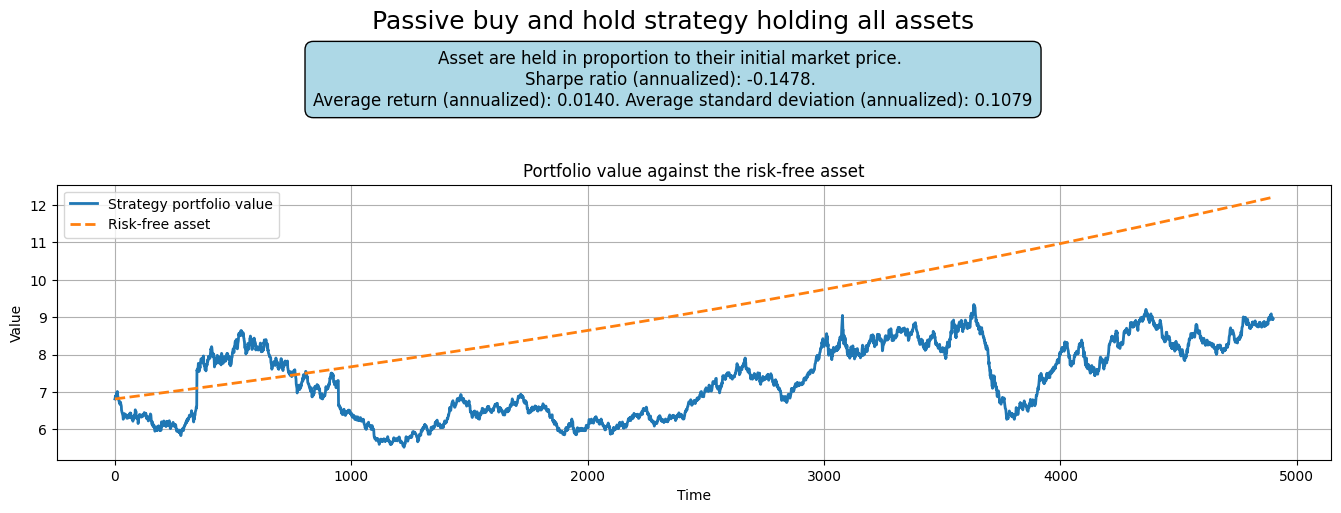

In [39]:
# Plot everything.
nrows =  1  
height_ratios = [3]

fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(nrows, 1, height_ratios=height_ratios, hspace=0.4)

# Title at the top
fig.suptitle("Passive buy and hold strategy holding all assets", fontsize=18)

strategy_returns=strategy_returns[~np.isnan(strategy_returns)] # Take waay any na values when computing mean and std for the text box, when computing the Sharpe Ratio above, we already took care of na values.

# Blue box as a figure-level annotation, not an axes
sharpe_text = (
    "Asset are held in proportion to their initial market price. \n"
    f"Sharpe ratio (annualized): {sharpe_ratio:.4f}. \n"
    f"Average return (annualized): {np.mean(strategy_returns) * 252:.4f}. "
    f"Average standard deviation (annualized): {np.std(strategy_returns) * np.sqrt(252):.4f}"
)
fig.text(
    0.5, 0.9,
    sharpe_text,
    fontsize=12,
    ha='center',
    va='top',
    multialignment='center',
    bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='round,pad=0.5')
)

# Plot starts lower to make room for the text box
ax1 = fig.add_subplot(gs[0])
ax1.set_position([0.06, 0.08, 0.91, 0.55])
ax1.plot(portfolio_value, label='Strategy portfolio value', linewidth=2)
ax1.plot(risk_free_asset, label='Risk-free asset', linestyle='--', linewidth=2)
ax1.set_title("Portfolio value against the risk-free asset")
ax1.set_xlabel("Time")
ax1.set_ylabel("Value")
ax1.legend()
ax1.grid(True)


plt.savefig("../ChannelBreakoutPlots/BH1.png")
plt.show()